In [3]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import re
import os
import sys
import datetime as dt

In [4]:
DATA_DIR = "../data/raw_data_phase2_v1"

In [6]:
df = pl.read_excel(
    os.path.join(DATA_DIR, "Encounters with Calculated Severity - 2.13.26.xlsx")
)

In [8]:
df['Calculated'].value_counts()

Calculated,count
str,u64
"""POA - 1""",1678
"""POA - 2""",1388
"""POA - 3""",1301
"""NPOA - 1""",73
"""NPOA - 3""",62
"""POA - 0""",107
"""NPOA - 2""",44


In [11]:
df['Sepsis_Category'].value_counts()

Sepsis_Category,count
str,u64
"""POA-1""",1681
"""UPOA-3""",77
"""POA-2""",775
"""NPOA-1""",218
"""NPOA-2""",44
"""UPOA-2""",76
"""POA-3""",863
"""UPOA-1""",617
"""NPOA-3""",302


In [32]:

df = df.with_columns(
    pl.col("Calculated")
      .str.replace_all(r"\s*-\s*", "-")
      .str.strip_chars()
      .alias("Calculated")
)

In [59]:
df=df.with_columns(
    pl.when(pl.col("Calculated")=="POA-0").then(pl.lit("NO-SEPSIS")).otherwise(pl.col("Calculated")).alias("Calculated")
)

In [82]:
df['Calculated'].value_counts().sort(by="Calculated")

Calculated,count
str,u64
"""NO-SEPSIS""",107
"""NPOA-1""",73
"""NPOA-2""",44
"""NPOA-3""",62
"""POA-1""",1678
"""POA-2""",1388
"""POA-3""",1301


In [83]:
df['Sepsis_Category'].value_counts().sort(by="Sepsis_Category")

Sepsis_Category,count
str,u64
"""NPOA-1""",218
"""NPOA-2""",44
"""NPOA-3""",302
"""POA-1""",1681
"""POA-2""",775
"""POA-3""",863
"""UPOA-1""",617
"""UPOA-2""",76
"""UPOA-3""",77


In [61]:
ORDER_COL=[
    "NPOA-1",
    "NPOA-2",
    "NPOA-3",
    "POA-1",
    "POA-2",
    "POA-3",
    "NO-SEPSIS",
]

In [62]:
col_true = "Sepsis_Category"
col_pred = "Calculated"
df_cm = (
    df
    .group_by([col_true, col_pred])
    .len()
    .pivot(
        values="len",
        index=col_true,
        columns=col_pred
    )
    .fill_null(0)
    .sort(col_true)
)
df_cm.select(["Sepsis_Category"]+ORDER_COL).to_pandas().set_index("Sepsis_Category")
# .with_columns(
#     pl.lit(0).alias("UPOA-1"),
#     pl.lit(0).alias("UPOA-2"),
#     pl.lit(0).alias("UPOA-3"),
# )
# cm_pd = df_cm.to_pandas().set_index(col_true)
# cm_pd.loc[:, cm_pd.index.to_list()+["POA-0"]]

/tmp/ipykernel_2336445/1275479508.py:4: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df


,NPOA-1,NPOA-2,NPOA-3,POA-1,POA-2,POA-3,NO-SEPSIS
Sepsis_Category,,,,,,,
NPOA-1,18,23,8,55,59,54,1
NPOA-2,1,5,2,9,14,13,0
NPOA-3,2,1,38,2,15,243,1
POA-1,18,9,2,956,551,111,34
POA-2,4,1,1,303,394,62,10
POA-3,2,1,5,30,120,704,1
UPOA-1,24,3,5,280,192,62,51
UPOA-2,2,0,0,30,31,9,4
UPOA-3,2,1,1,13,12,43,5


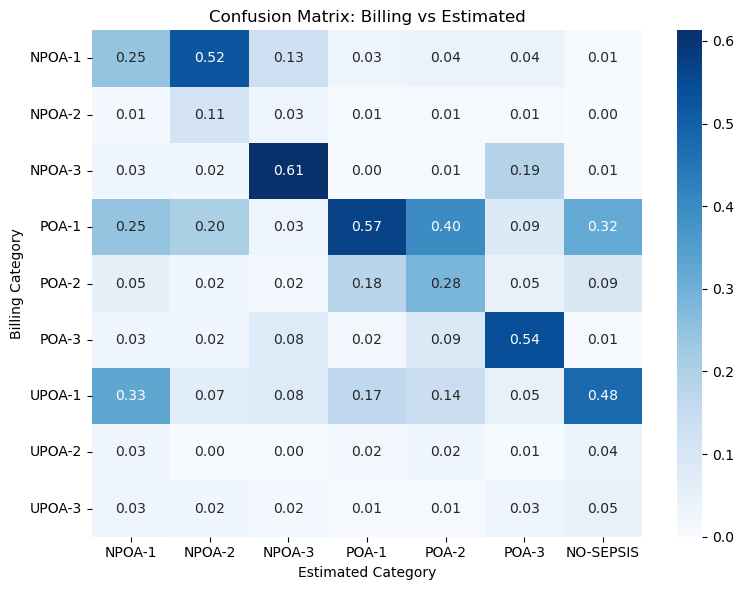

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_pd = df_cm.select(["Sepsis_Category"]+ORDER_COL).to_pandas().set_index("Sepsis_Category")

cm_col_norm = cm_pd.div(cm_pd.sum(axis=0), axis=1)
cm_row_norm = cm_pd.div(cm_pd.sum(axis=1), axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_col_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Confusion Matrix: Billing vs Estimated")
plt.ylabel("Billing Category")
plt.xlabel("Estimated Category")
plt.tight_layout()
plt.show()


In [38]:
from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(df['Calculated'].to_numpy(), df['Sepsis_Category'].to_numpy())

0.2883663618415906

In [53]:
df.filter(pl.col("Calculated")==pl.col("Sepsis_Category"))['Calculated'].value_counts().sort(by="Calculated").join(
    df.filter(pl.col("Calculated")!=pl.col("Sepsis_Category"))['Calculated'].value_counts().sort(by="Calculated"),
    on="Calculated",
    suffix="_mismatch"
).rename({"Calculated":"Category", "count":"n_matches", "count_mismatch":"n_mismatches"}).with_columns(pl.sum_horizontal(["n_matches", "n_mismatches"]).alias("total"))\
    .with_columns(
        (pl.col("n_matches")/pl.col("total")).alias("%matches"),
        (pl.col("n_mismatches")/pl.col("total")).alias("%mis_matches"),
    )

Category,n_matches,n_mismatches,total,%matches,%mis_matches
str,u64,u64,u64,f64,f64
"""NPOA-1""",18,55,73,0.246575,0.753425
"""NPOA-2""",5,39,44,0.113636,0.886364
"""NPOA-3""",38,24,62,0.612903,0.387097
"""POA-1""",956,722,1678,0.569726,0.430274
"""POA-2""",394,994,1388,0.283862,0.716138
"""POA-3""",704,597,1301,0.541122,0.458878


In [57]:
df_mismatches = df.filter(pl.col("Calculated")!=pl.col("Sepsis_Category"))

In [84]:
df.filter(
    (pl.col("Calculated")=='POA-3')&
    (pl.col("Sepsis_Category")=='NPOA-3')
)

PrimaryMrn,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,Suspected Infection Time,Sepsis Time,Severe Sepsis Time,Septic Shock Time,Sepsis Exists,Severe Sepsis Exists,Septic Shock Exists,Calculated,arrival_2_s1_hrs
i64,i64,date,date,datetime[ms],datetime[ms],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,i64,i64,i64,f64,f64,f64,f64,f64,datetime[ms],datetime[ms],datetime[ms],datetime[ms],i64,i64,i64,str,f64
95562977,725390246,2025-04-15,2025-05-06,2025-04-15 10:40:00,2025-04-16 16:32:00,"""Yes""","""Inpatient""","""Observation""","""MICU""","""UH 12B""","""UH 07B ICU""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute hypoxemic respiratory fa…","""Secondary malignant neoplasm o…","""Respiratory Ventilation, Great…",1,"""NPOA-3""","""NPOA-3""",130,16,75,0.715,120.235294,2.50303,85.558824,6.670909,2025-04-15 12:31:00,2025-04-15 16:11:00,2025-04-17 14:20:00,2025-04-17 23:51:45,1,1,1,"""POA-3""",5.516667
98943674,725960018,2025-04-22,2025-05-31,2025-04-22 17:15:00,2025-04-22 17:15:00,"""No""","""Inpatient""","""Inpatient""","""MICU""","""UH 11O""","""UH 08B MICU""","""Urgent""","""Physician Ofc/OP Clinic""","""Direct Admission""","""Hemoptysis""","""Malignant neoplasm of upper lo…","""Destruction of Left Upper Lung…",1,"""NPOA-3""","""NPOA-3""",99,16,101,null,null,null,null,null,2025-04-22 21:37:43,2025-04-23 04:00:25,2025-04-23 00:51:00,2025-05-29 03:13:05,1,1,1,"""POA-3""",10.756944
98933321,727441497,2025-05-19,2025-06-07,2025-05-19 01:20:00,2025-05-19 01:20:00,"""No""","""Inpatient""","""Inpatient""","""IM - Teaching""","""UH 10B HRT LNG""","""UH 10G""","""Urgent""","""Trans from Short Term General …","""Transfer Center Admission""","""Shock (*)""","""Centrilobular emphysema (*)""","""Occlusion of Lower Artery with…",0,"""NPOA-3""","""NPOA-3""",129,18,72,null,null,null,null,null,2025-05-19 19:44:30,2025-05-19 07:55:00,2025-05-19 22:05:00,2025-05-20 00:29:29,1,1,1,"""POA-3""",6.583333
96666626,728105178,2025-05-23,2025-06-27,2025-05-23 14:34:00,2025-05-23 20:18:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 10O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Septic shock (*)""","""Human immunodeficiency virus (…","""Excision of Right Upper Lung L…",0,"""NPOA-3""","""NPOA-3""",null,null,null,null,null,null,null,null,2025-05-23 15:39:00,2025-05-25 06:34:00,2025-06-03 10:50:00,2025-06-03 14:04:01,1,1,1,"""POA-3""",40.0
70385593,728503997,2025-05-30,2025-11-21,2025-05-30 15:49:00,2025-05-30 19:57:00,"""Yes""","""Inpatient""","""Inpatient""","""CICU""","""UH 07B ICU""","""UH 10B HRT LNG""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Cardiogenic shock (*)""","""Hypertensive heart and chronic…","""Insert Heart Asist Cnduit in R…",0,"""NPOA-3""","""NPOA-3""",null,null,null,2.134,196.0,3.7,35.5,8.031667,2025-06-05 21:08:51,2025-05-30 16:51:00,2025-06-01 21:48:00,2025-06-05 19:24:15,1,1,1,"""POA-3""",1.033333
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
70881690,739130287,2025-10-26,2025-12-04,2025-10-26 14:52:00,2025-10-26 23:54:00,"""Yes""","""Inpatient""","""Inpatient""","""Oncology - Solid Tumor""","""UH 09O""","""UH 11G ONC""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Goals of care, counseling/disc…","""Secondary malignant neoplasm o…","""Excision of Cerebral Hemispher…",1,"""NPOA-3""","""NPOA-3""",108,18,103,0.471336,406.171875,0.423846,122.773913,26.597734,2025-10-29 16:46:38,2025-10-26 14:00

/tmp/ipykernel_2336445/15816297.py:8: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df


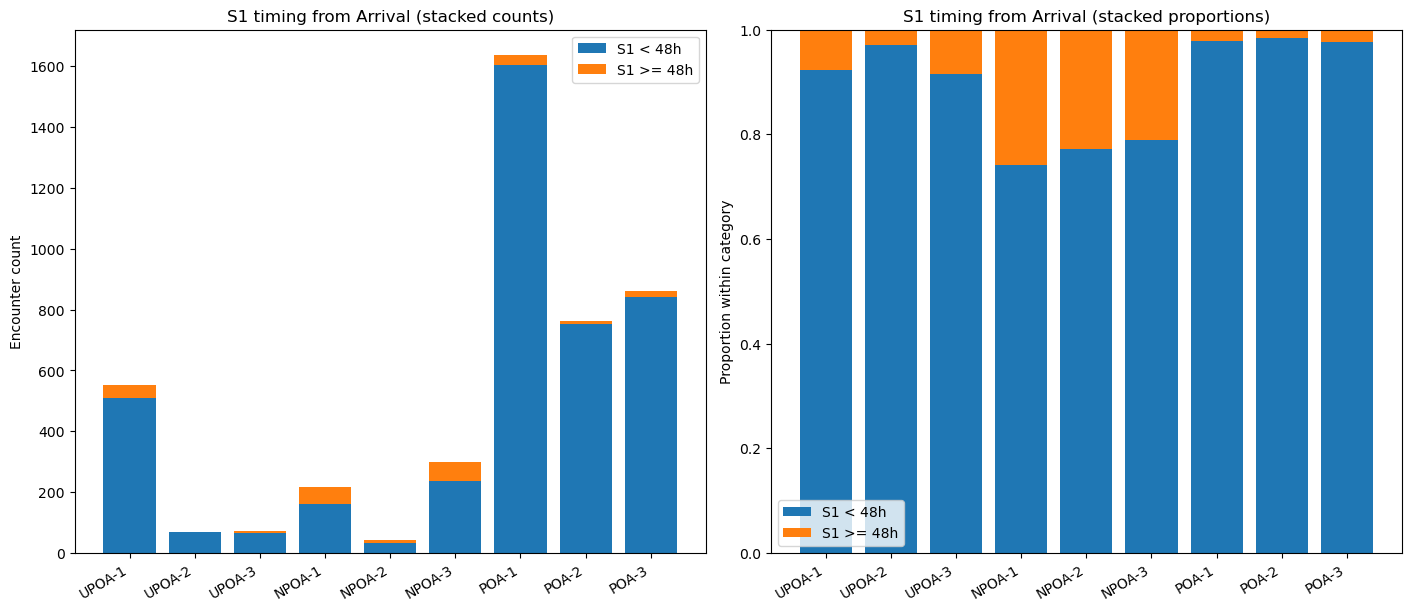

In [74]:
THRESH_HRS = 48
ORDER_COLS=["UPOA-1", "UPOA-2", "UPOA-3", "NPOA-1", "NPOA-2", "NPOA-3", "POA-1", "POA-2", "POA-3"]
# ----- Build stacked counts per category -----
df = df.with_columns(
    (pl.col("Sepsis Time")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival_2_s1_hrs")
)
df_stack = (
    df
    .filter(pl.col("arrival_2_s1_hrs").is_not_null())
    .with_columns(
        pl.when(pl.col("arrival_2_s1_hrs") < THRESH_HRS)
          .then(pl.lit("lt_48h"))
          .otherwise(pl.lit("ge_48h"))
          .alias("bucket")
    )
    .group_by(["Sepsis_Category", "bucket"])
    .len()
    .rename({"len": "n"})
    .pivot(
        values="n",
        index="Sepsis_Category",
        columns="bucket",
        aggregate_function="first"
    )
    .with_columns([
        pl.col("lt_48h").fill_null(0),
        pl.col("ge_48h").fill_null(0),
    ])
    .with_columns([
        (pl.col("lt_48h") + pl.col("ge_48h")).alias("total"),
        (pl.when((pl.col("lt_48h") + pl.col("ge_48h")) > 0)
           .then(pl.col("lt_48h") / (pl.col("lt_48h") + pl.col("ge_48h")))
           .otherwise(0.0)
        ).alias("p_lt"),
        (pl.when((pl.col("lt_48h") + pl.col("ge_48h")) > 0)
           .then(pl.col("ge_48h") / (pl.col("lt_48h") + pl.col("ge_48h")))
           .otherwise(0.0)
        ).alias("p_ge"),
    ])
)

# ----- Force ORDER_COLS (and include missing cats as 0s) -----
df_order = pl.DataFrame({"Sepsis_Category": ORDER_COLS})

df_stack = (
    df_order.join(df_stack, on="Sepsis_Category", how="left")
    .with_columns([
        pl.col("lt_48h").fill_null(0),
        pl.col("ge_48h").fill_null(0),
        pl.col("total").fill_null(0),
        pl.col("p_lt").fill_null(0.0),
        pl.col("p_ge").fill_null(0.0),
    ])
)

pdf = df_stack.to_pandas()

cats = pdf["Sepsis_Category"].tolist()
x = np.arange(len(cats))

n_lt = pdf["lt_48h"].to_numpy()
n_ge = pdf["ge_48h"].to_numpy()

p_lt = pdf["p_lt"].to_numpy()
p_ge = pdf["p_ge"].to_numpy()

# ----- Plot -----
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Stacked counts
axes[0].bar(x, n_lt, label="S1 < 48h")
axes[0].bar(x, n_ge, bottom=n_lt, label="S1 >= 48h")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats, rotation=30, ha="right")
axes[0].set_ylabel("Encounter count")
axes[0].set_title("S1 timing from Arrival (stacked counts)")

# Stacked proportions
axes[1].bar(x, p_lt, label="S1 < 48h")
axes[1].bar(x, p_ge, bottom=p_lt, label="S1 >= 48h")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, rotation=30, ha="right")
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Proportion within category")
axes[1].set_title("S1 timing from Arrival (stacked proportions)")

for ax in axes:
    ax.legend()

plt.show()


In [85]:

df_med = pl.read_csv(os.path.join(DATA_DIR, "Med Admin - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_flow = pl.read_csv(os.path.join(DATA_DIR, "Flowsheet - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_flow_sbp = pl.read_csv(os.path.join(DATA_DIR, "Flowsheet SBP - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_enc = pl.read_csv(os.path.join(DATA_DIR, "Encounter Table with Baseline Values and Infection Suspicion - Feb 2025 - Jan 2026.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_diag = pl.read_csv(os.path.join(DATA_DIR, "Diagnosis Events - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_sirs = pl.read_csv(os.path.join(DATA_DIR, "SIRS Score Over Time - 2.10.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_lab = pl.read_csv(os.path.join(DATA_DIR, 'Lab Results - 2.10.26.csv'),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_proc = pl.read_csv(os.path.join(DATA_DIR, 'Procedure Orders - 2.9.26.csv'),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_sever = pl.read_csv(os.path.join(DATA_DIR, "Severe Sepsis and Septic Shock Flags Over Time - 2.10.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])

df_severe_updated = pl.read_csv(os.path.join(DATA_DIR, "Encounters with Calculated Severity - 2.13.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])


In [86]:

expr = pl.col("NumericValue").cast(pl.Utf8)
df_diag = df_diag.with_columns(expr)
df_med = df_med.with_columns(expr)
df_flow = df_flow.with_columns(expr)
df_flow_sbp = df_flow_sbp.with_columns(expr)
df_proc = df_proc.with_columns(expr)
df_lab = df_lab.with_columns(expr)

In [87]:
df_events = pl.concat(
    [df_diag, df_med, df_flow, df_flow_sbp, df_proc, df_lab]
)

In [90]:
df_events_enc = df_events.join(
    df_severe_updated, on="EncounterEpicCsn"
)

In [92]:
df_events_enc.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'Suspected Infection Time',
 'Sepsis Time',
 'Severe Sepsis Time',
 'Septic Shock Time',
 'Sepsis Exists',
 'Severe Sepsis Exists',
 'Septic Shock Exists',
 'Calculated']

In [93]:
datetime_cols = [
    "Event_DateTime",
    "Arrival_Instant",
    "InpatientAdmissionInstant",
    # "Suspected_Infection_Time",
]
for col in datetime_cols:
    if df_events_enc.schema[col] == pl.Utf8:
        df_events_enc = df_events_enc.with_columns(
            pl.col(col).str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f", strict=False)
		)

In [95]:
df_events_enc = df_events_enc.sort(by=['EncounterEpicCsn', "Event_DateTime"])

In [98]:
df_events_enc.filter(
    pl.col("EncounterEpicCsn")==731680219
).select("EncounterEpicCsn", "Event_DateTime", "Type", "Event_Grouper", "Event_Name", "Value",  "Sepsis_Category", "Calculated").to_pandas()

,EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,Value,Sepsis_Category,Calculated
0,731680219,2025-07-20 01:49:49,Diagnosis Event,Hospital Problem,Septic shock with acute organ dysfunction due ...,R65.21,POA-3,POA - 0
1,731680219,2025-07-20 01:49:49,Diagnosis Event,Encounter Diagnosis,Generalized weakness,R53.1,POA-3,POA - 0
2,731680219,2025-07-20 01:49:49,Diagnosis Event,Hospital Problem,Septic shock with acute organ dysfunction due ...,A41.53,POA-3,POA - 0
3,731680219,2025-07-20 15:00:00,Flowsheet,Temperature,TEMPERATURE,97.9,POA-3,POA - 0
4,731680219,2025-07-20 15:00:00,Flowsheet,O2 Flow Rate,CPM S25 R INV O2 FLOW RATE (L/MIN),1,POA-3,POA - 0
...,...,...,...,...,...,...,...,...
575,731680219,2025-07-29 02:28:18,Diagnosis Event,Billing Diagnosis,Secondary pulmonary arterial hypertension (*),I27.21,POA-3,POA - 0
576,731680219,2025-07-29 02:28:18,Diagnosis Event,Billing Diagnosis,Family history of ischemic heart disease and o...,Z82.49,POA-3,POA - 0
577,731680219,2025-07-29 02:28:18,Diagnosis Event,Billing Diagnosis,"Anxiety disorder, unspecified",F41.9,POA-3,POA - 0
578,731680219,2025-08-02 02:03:38,Diagnosis Event,Billing Diagnosis,Sepsis due to Serratia (*),A41.53,POA-3,POA - 0


In [99]:
df_events_enc.filter(
    pl.col("EncounterEpicCsn")==732044391
).select("EncounterEpicCsn", "Event_DateTime", "Type", "Event_Grouper", "Event_Name", "Value",  "Sepsis_Category", "Calculated").to_pandas()

,EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,Value,Sepsis_Category,Calculated
0,732044391,2025-07-24 18:15:00,Flowsheet,Systolic Blood Pressure,BLOOD PRESSURE,123/67,POA-2,POA - 0
1,732044391,2025-07-24 18:15:00,Flowsheet,Blood Pressure,BLOOD PRESSURE,123/67,POA-2,POA - 0
2,732044391,2025-07-24 20:13:00,Procedure Order,Blood Culture Order,CULTURE BLOOD,None,POA-2,POA - 0
3,732044391,2025-07-24 20:13:00,Procedure Order,Blood Culture Order,CULTURE BLOOD,None,POA-2,POA - 0
4,732044391,2025-07-24 20:27:00,Procedure Order,Imaging,US ABDOMEN,None,POA-2,POA - 0
...,...,...,...,...,...,...,...,...
892,732044391,2025-08-08 12:41:23,Diagnosis Event,Billing Diagnosis,Hypertensive chronic kidney disease with stage...,I12.9,POA-2,POA - 0
893,732044391,2025-08-08 12:41:23,Diagnosis Event,Billing Diagnosis,Autistic disorder,F84.0,POA-2,POA - 0
894,732044391,2025-08-08 12:41:23,Diagnosis Event,Billing Diagnosis,Severe sepsis without septic shock (*),R65.20,POA-2,POA - 0
895,732044391,2025-08-08 12:41:23,Diagnosis Event,Billing Diagnosis,"Gram-negative sepsis, unspecified (*)",A41.50,POA-2,POA - 0


In [ ]:
732044391